<a href="https://colab.research.google.com/github/ninobronw/BPALM-TOOL-IMPLEMENTATION/blob/main/Full_Code_SuperKart_Model_Deployment_Notebook_%5BUpdated%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [20]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.7/558.7 kB 35.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.34.0 which is incompatible.
transformers 5.13.1 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.34.0 which is incompatible.


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [21]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [22]:
import pandas as pd

# Charger le dataset (remplacez 'superkart_sales.csv' par le nom de votre fichier)
data = pd.read_csv('/content/SuperKart.csv')

# Afficher les 5 premières lignes
print(data.head())

# Statistiques descriptives
print(data.describe())

# Informations sur les colonnes
print(data.info())

# Vérifier les valeurs manquantes
print(data.isnull().sum())

  Product_Id  Product_Weight Product_Sugar_Content  Product_Allocated_Area  \
0     FD6114           12.66             Low Sugar                   0.027   
1     FD7839           16.54             Low Sugar                   0.144   
2     FD5075           14.28               Regular                   0.031   
3     FD8233           12.10             Low Sugar                   0.112   
4     NC1180            9.57              No Sugar                   0.010   

         Product_Type  Product_MRP Store_Id  Store_Establishment_Year  \
0        Frozen Foods       117.08   OUT004                      2009   
1               Dairy       171.43   OUT003                      1999   
2              Canned       162.08   OUT001                      1987   
3        Baking Goods       186.31   OUT001                      1987   
4  Health and Hygiene       123.67   OUT002                      1998   

  Store_Size Store_Location_City_Type          Store_Type  \
0     Medium                   

# **Data Overview**

In [23]:
# Charger le dataset (remplacez 'superkart_sales.csv' par le nom de votre fichier)
data = pd.read_csv('/content/SuperKart.csv')

# Afficher les 5 premières lignes
print(data.head())

# Statistiques descriptives
print(data.describe())

# Informations sur les colonnes
print(data.info())

# Vérifier les valeurs manquantes
print(data.isnull().sum())

  Product_Id  Product_Weight Product_Sugar_Content  Product_Allocated_Area  \
0     FD6114           12.66             Low Sugar                   0.027   
1     FD7839           16.54             Low Sugar                   0.144   
2     FD5075           14.28               Regular                   0.031   
3     FD8233           12.10             Low Sugar                   0.112   
4     NC1180            9.57              No Sugar                   0.010   

         Product_Type  Product_MRP Store_Id  Store_Establishment_Year  \
0        Frozen Foods       117.08   OUT004                      2009   
1               Dairy       171.43   OUT003                      1999   
2              Canned       162.08   OUT001                      1987   
3        Baking Goods       186.31   OUT001                      1987   
4  Health and Hygiene       123.67   OUT002                      1998   

  Store_Size Store_Location_City_Type          Store_Type  \
0     Medium                   

# **Exploratory Data Analysis (EDA)**

=== Analyse univariée des ventes ===
count    8763.000000
mean     3464.003640
std      1065.630494
min        33.000000
25%      2761.715000
50%      3452.340000
75%      4145.165000
max      8000.000000
Name: Product_Store_Sales_Total, dtype: float64


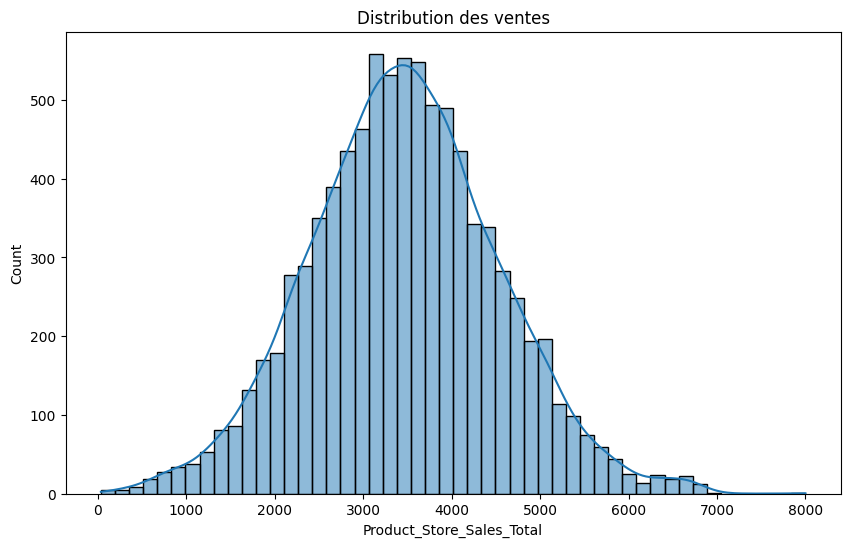


=== Analyse bivariée : Ventes vs Prix ===


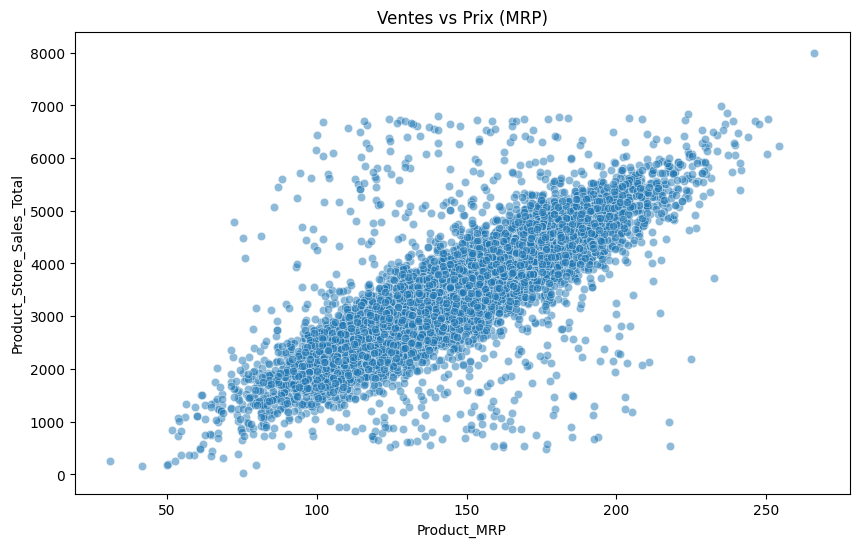

Corrélation de Pearson : 0.788

=== Analyse bivariée : Ventes par type de magasin ===


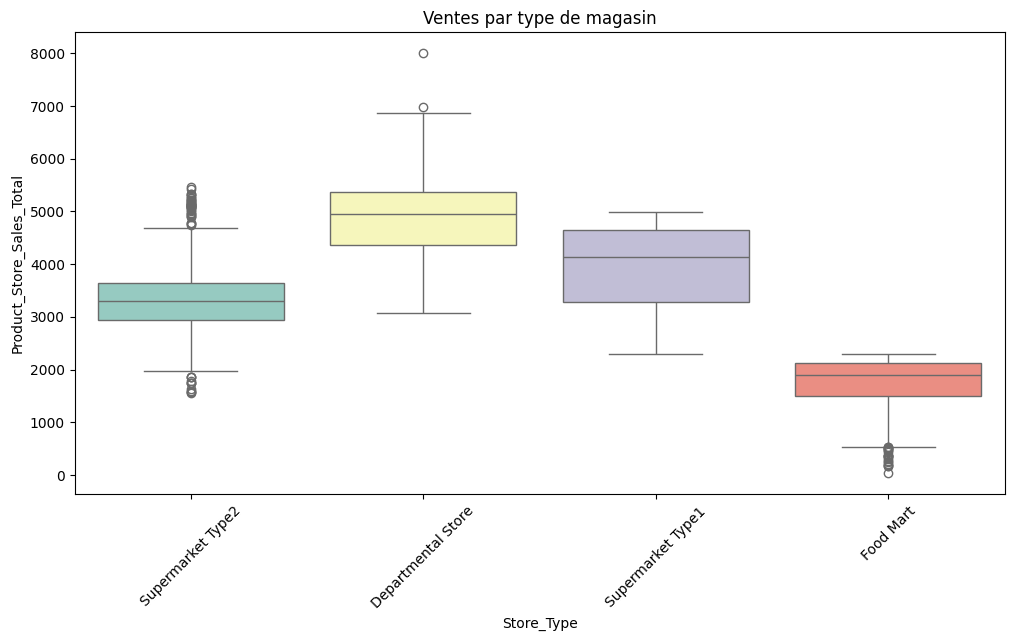

Store_Type
Departmental Store    4946.966323
Supermarket Type1     3923.778802
Supermarket Type2     3299.312111
Food Mart             1762.942465
Name: Product_Store_Sales_Total, dtype: float64

=== Analyse bivariée : Ventes par type de ville ===


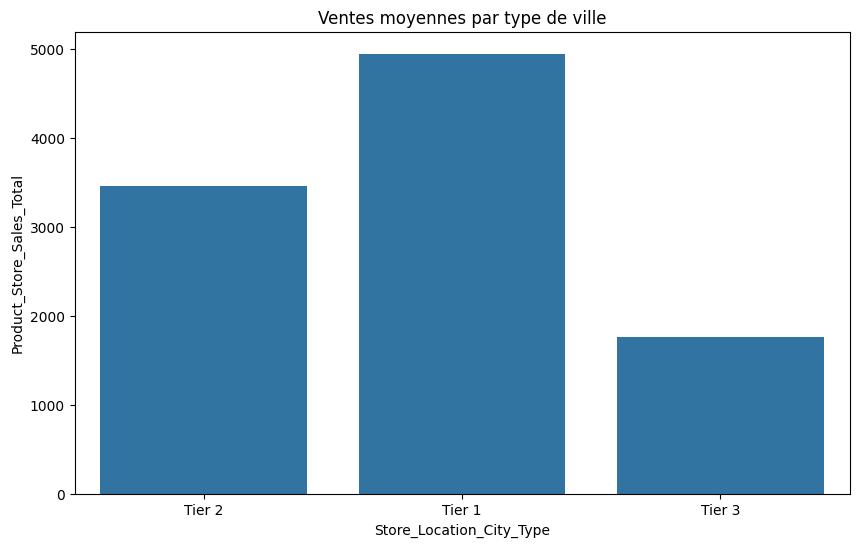

Store_Location_City_Type
Tier 1    4946.966323
Tier 2    3457.473109
Tier 3    1762.942465
Name: Product_Store_Sales_Total, dtype: float64


In [24]:
# 1. Analyse univariée de la variable cible (ventes)
print("=== Analyse univariée des ventes ===")
print(data['Product_Store_Sales_Total'].describe())
plt.figure(figsize=(10, 6))
sns.histplot(data['Product_Store_Sales_Total'], bins=50, kde=True)
plt.title("Distribution des ventes")
plt.show()

# 2. Analyse bivariée : Ventes vs Prix (MRP)
print("\n=== Analyse bivariée : Ventes vs Prix ===")
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Product_MRP', y='Product_Store_Sales_Total', data=data, alpha=0.5)
plt.title("Ventes vs Prix (MRP)")
plt.show()
print(f"Corrélation de Pearson : {np.corrcoef(data['Product_MRP'], data['Product_Store_Sales_Total'])[0, 1]:.3f}")

# 3. Analyse bivariée : Ventes par type de magasin
print("\n=== Analyse bivariée : Ventes par type de magasin ===")
plt.figure(figsize=(12, 6))
sns.boxplot(x='Store_Type', y='Product_Store_Sales_Total', data=data, palette='Set3')
plt.title("Ventes par type de magasin")
plt.xticks(rotation=45)
plt.show()
print(data.groupby('Store_Type')['Product_Store_Sales_Total'].mean().sort_values(ascending=False))

# 4. Analyse bivariée : Ventes par type de ville
print("\n=== Analyse bivariée : Ventes par type de ville ===")
plt.figure(figsize=(10, 6))
sns.barplot(x='Store_Location_City_Type', y='Product_Store_Sales_Total', data=data, estimator=np.mean, ci=None)
plt.title("Ventes moyennes par type de ville")
plt.show()
print(data.groupby('Store_Location_City_Type')['Product_Store_Sales_Total'].mean())

## Univariate Analysis

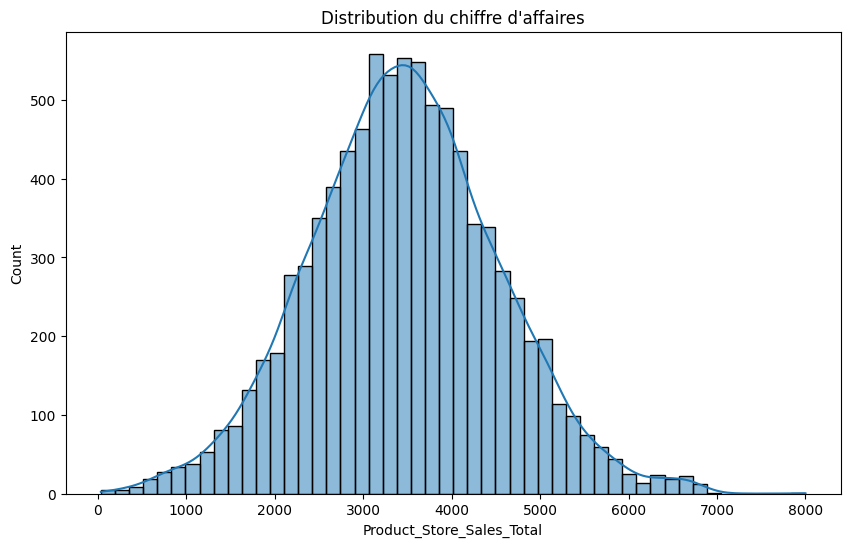

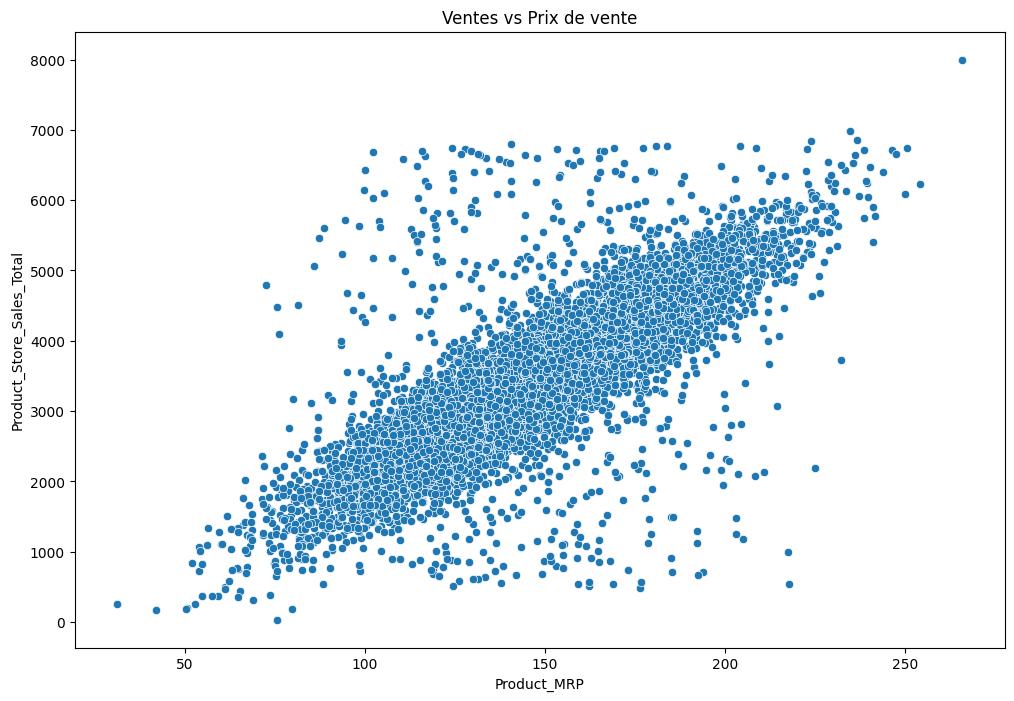

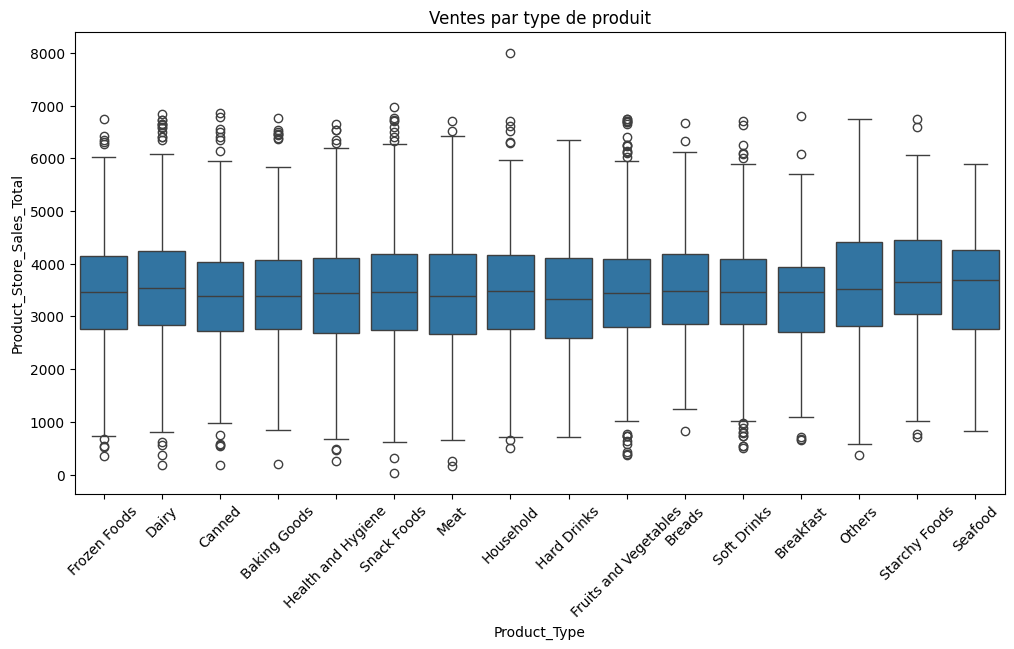

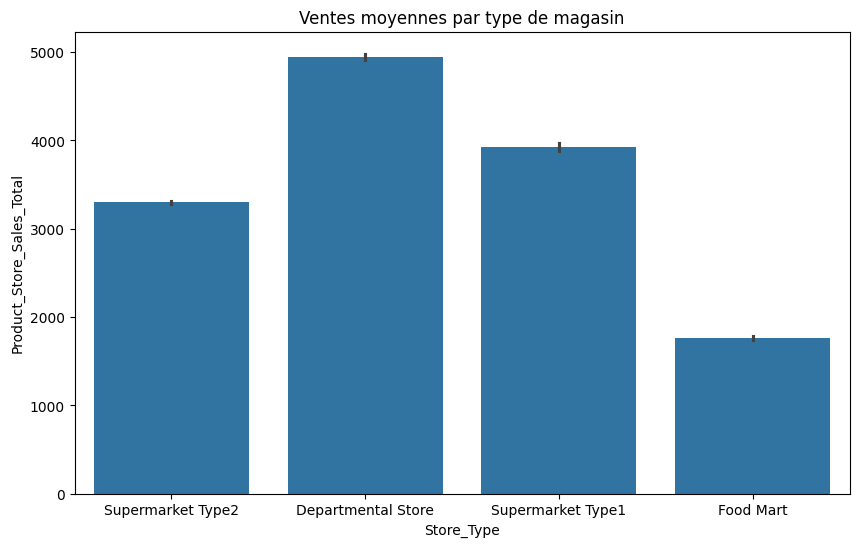

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Distribution de la variable cible
plt.figure(figsize=(10, 6))
sns.histplot(data['Product_Store_Sales_Total'], bins=50, kde=True)
plt.title('Distribution du chiffre d\'affaires')
plt.show()

# Relation entre les ventes et les variables numériques
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Product_MRP', y='Product_Store_Sales_Total', data=data)
plt.title('Ventes vs Prix de vente')
plt.show()

# Analyse par type de produit
plt.figure(figsize=(12, 6))
sns.boxplot(x='Product_Type', y='Product_Store_Sales_Total', data=data)
plt.xticks(rotation=45)
plt.title('Ventes par type de produit')
plt.show()

# Analyse par type de magasin
plt.figure(figsize=(10, 6))
sns.barplot(x='Store_Type', y='Product_Store_Sales_Total', data=data, estimator=np.mean)
plt.title('Ventes moyennes par type de magasin')
plt.show()

### Analyse univariée des variables numériques restantes

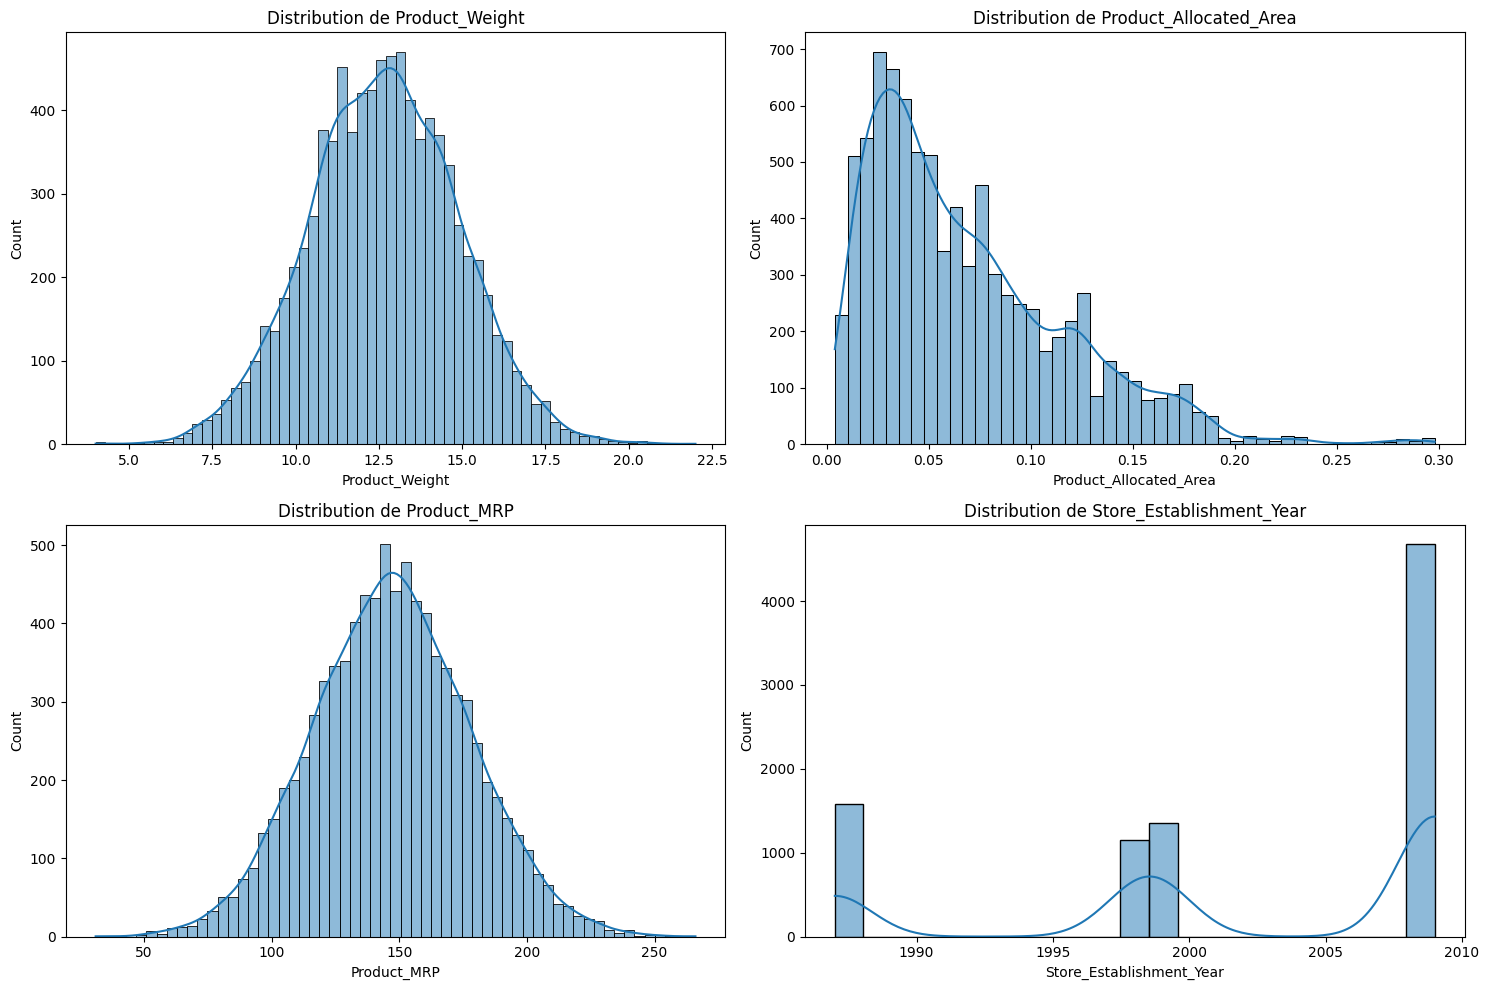

In [26]:
# Sélectionner les colonnes numériques (à l'exception de la variable cible déjà analysée)
numerical_cols = data.select_dtypes(include=['number']).columns.tolist()
if 'Product_Store_Sales_Total' in numerical_cols:
    numerical_cols.remove('Product_Store_Sales_Total')

# Créer des histogrammes pour chaque variable numérique
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1) # Ajustez la grille selon le nombre de colonnes numériques
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution de {col}')
plt.tight_layout()
plt.show()

### Analyse univariée des variables catégorielles

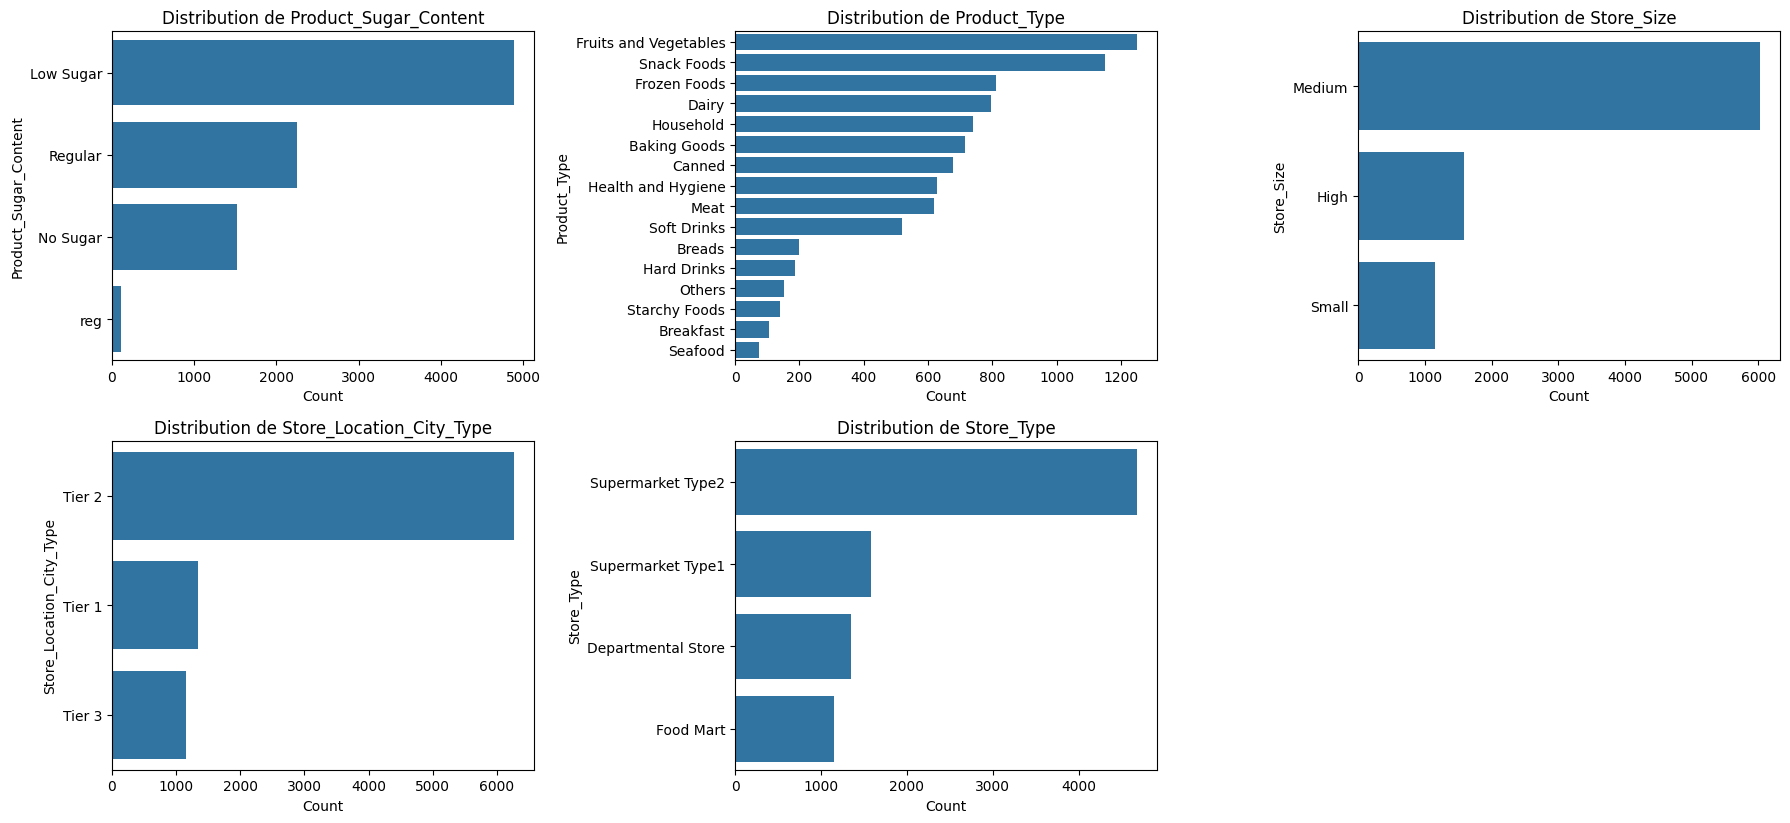

In [27]:
# Sélectionner les colonnes catégorielles
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
# Exclure 'Product_Id' et 'Store_Id' si elles sont purement des identifiants et non des catégories pour l'analyse
exclusion_list = ['Product_Id', 'Store_Id']
categorical_cols = [col for col in categorical_cols if col not in exclusion_list]

# Créer des countplots pour chaque variable catégorielle
plt.figure(figsize=(18, 12)) # Ajustez la taille de la figure
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1) # Ajustez la grille selon le nombre de colonnes catégorielles
    sns.countplot(y=col, data=data, order = data[col].value_counts().index)
    plt.title(f'Distribution de {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

## Bivariate Analysis

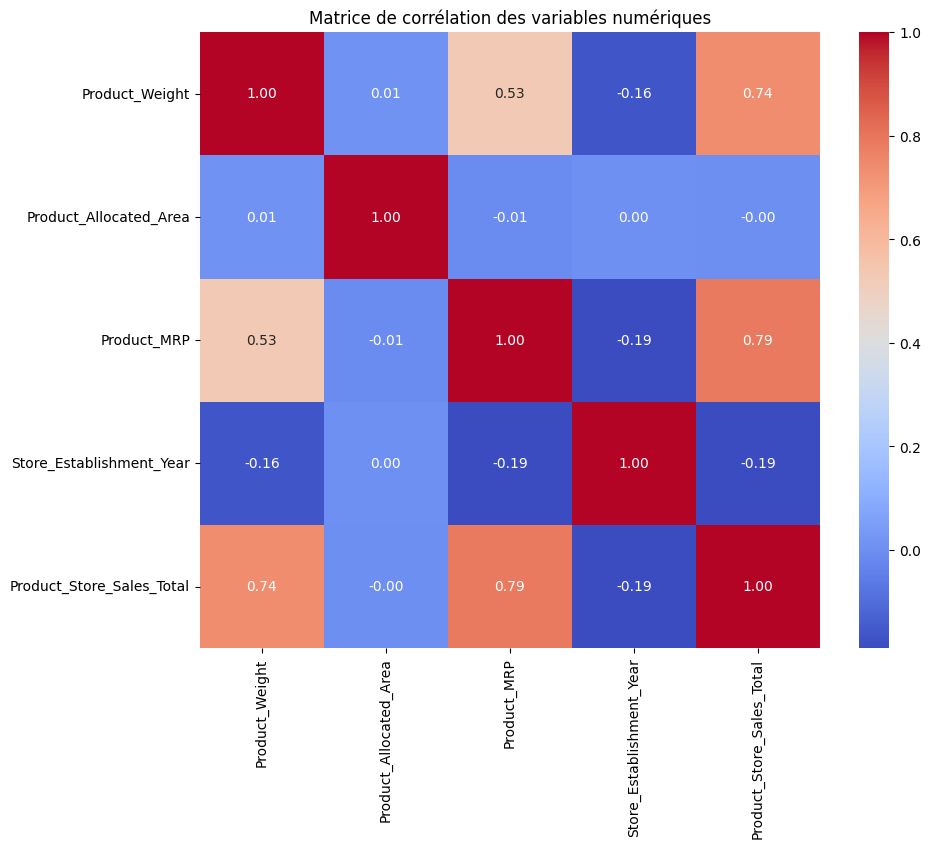

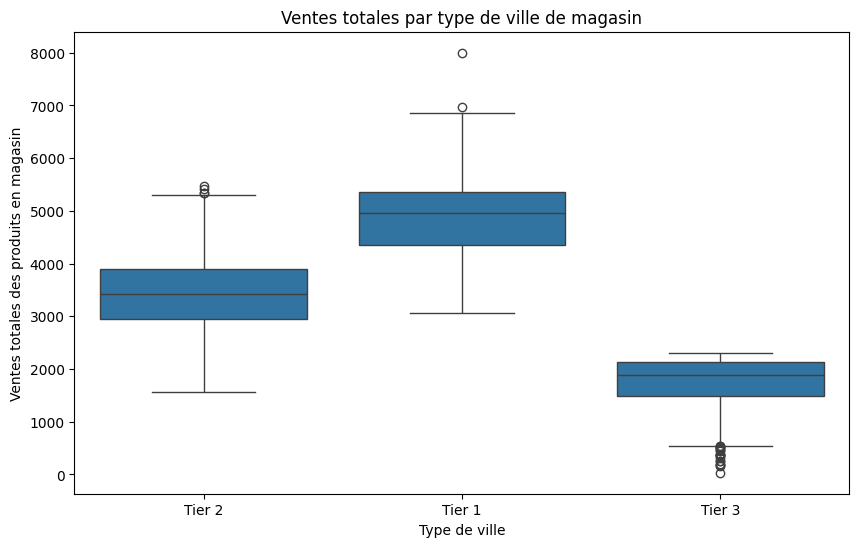

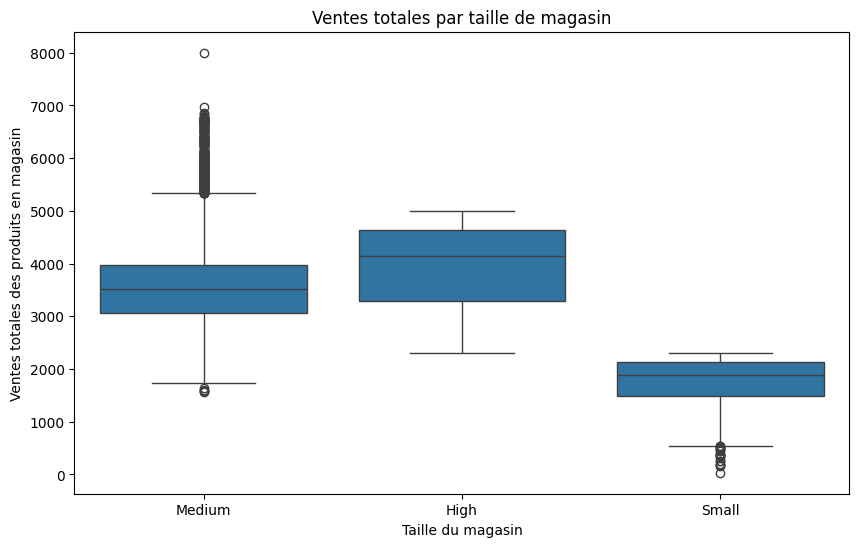

In [28]:
# Analyse de corrélation pour les variables numériques
plt.figure(figsize=(10, 8))
sns.heatmap(data.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de corrélation des variables numériques')
plt.show()

# Box plot des ventes par type de ville
plt.figure(figsize=(10, 6))
sns.boxplot(x='Store_Location_City_Type', y='Product_Store_Sales_Total', data=data)
plt.title('Ventes totales par type de ville de magasin')
plt.xlabel('Type de ville')
plt.ylabel('Ventes totales des produits en magasin')
plt.show()

# Box plot des ventes par taille de magasin
plt.figure(figsize=(10, 6))
sns.boxplot(x='Store_Size', y='Product_Store_Sales_Total', data=data)
plt.title('Ventes totales par taille de magasin')
plt.xlabel('Taille du magasin')
plt.ylabel('Ventes totales des produits en magasin')
plt.show()

# **Data Preprocessing**

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données
data = pd.read_csv('/content/SuperKart.csv')  # Remplace par ton fichier

# Afficher les 5 premières lignes
print("=== Aperçu des données ===")
print(data.head())

# Informations générales
print("\n=== Infos générales ===")
print(data.info())

# Statistiques descriptives
print("\n=== Statistiques descriptives ===")
print(data.describe(include='all'))

# Vérifier les valeurs manquantes
print("\n=== Valeurs manquantes ===")
print(data.isnull().sum())# Supprimer les lignes avec des valeurs manquantes (si peu de données)
data_clean = data.dropna()

# Ou imputer les valeurs manquantes
from sklearn.impute import SimpleImputer

# Pour les variables numériques : imputer avec la médiane
num_imputer = SimpleImputer(strategy='median')
data[['Product_Weight', 'Product_MRP']] = num_imputer.fit_transform(data[['Product_Weight', 'Product_MRP']])

# Pour les variables catégorielles : imputer avec le mode
cat_imputer = SimpleImputer(strategy='most_frequent')
data[['Product_Type', 'Store_Type']] = cat_imputer.fit_transform(data[['Product_Type', 'Store_Type']])

=== Aperçu des données ===
  Product_Id  Product_Weight Product_Sugar_Content  Product_Allocated_Area  \
0     FD6114           12.66             Low Sugar                   0.027   
1     FD7839           16.54             Low Sugar                   0.144   
2     FD5075           14.28               Regular                   0.031   
3     FD8233           12.10             Low Sugar                   0.112   
4     NC1180            9.57              No Sugar                   0.010   

         Product_Type  Product_MRP Store_Id  Store_Establishment_Year  \
0        Frozen Foods       117.08   OUT004                      2009   
1               Dairy       171.43   OUT003                      1999   
2              Canned       162.08   OUT001                      1987   
3        Baking Goods       186.31   OUT001                      1987   
4  Health and Hygiene       123.67   OUT002                      1998   

  Store_Size Store_Location_City_Type          Store_Type  \
0   

# **Model Building**

## Define functions for Model Evaluation

In [30]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

# Séparer les colonnes
numeric_cols = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year']
categorical_cols = ['Product_Sugar_Content', 'Product_Type', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']

# Préparer les transformateurs
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Remplacer les NaN par la médiane
    ('scaler', StandardScaler())  # Standardisation
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Remplacer les NaN par le mode
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))  # One-Hot Encoding
])

# Combiner les transformateurs
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Pipeline complet (prétraitement + modèle)
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42))
])

# Séparation train/test
X = data.drop('Product_Store_Sales_Total', axis=1)
y = data['Product_Store_Sales_Total']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entraînement
model_pipeline.fit(X_train, y_train)

# Évaluation
from sklearn.metrics import mean_absolute_error
y_pred = model_pipeline.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE sur le jeu de test : {mae:.2f}")

MAE sur le jeu de test : 121.17


In [38]:
df_perf = model_performance_regression(model_pipeline, X_test, y_test)
display(df_perf)

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,288.535209,121.171635,0.927037,0.926576,0.044356


The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

[0]	validation_0-mae:764.29131
[1]	validation_0-mae:695.77975
[2]	validation_0-mae:634.97026
[3]	validation_0-mae:583.91318
[4]	validation_0-mae:532.67797
[5]	validation_0-mae:487.53958
[6]	validation_0-mae:450.86599
[7]	validation_0-mae:418.27520
[8]	validation_0-mae:384.99925
[9]	validation_0-mae:357.78666
[10]	validation_0-mae:334.30161
[11]	validation_0-mae:309.74481
[12]	validation_0-mae:287.33920
[13]	validation_0-mae:267.83546
[14]	validation_0-mae:252.53909
[15]	validation_0-mae:239.80142
[16]	validation_0-mae:226.05406
[17]	validation_0-mae:214.32619
[18]	validation_0-mae:206.44256
[19]	validation_0-mae:200.23269
[20]	validation_0-mae:194.83388
[21]	validation_0-mae:190.67825
[22]	validation_0-mae:185.12353
[23]	validation_0-mae:181.57116
[24]	validation_0-mae:176.55139
[25]	validation_0-mae:170.58514
[26]	validation_0-mae:165.63659
[27]	validation_0-mae:161.31086
[28]	validation_0-mae:156.69228
[29]	validation_0-mae:152.92314
[30]	validation_0-mae:151.19873
[31]	validation_0-

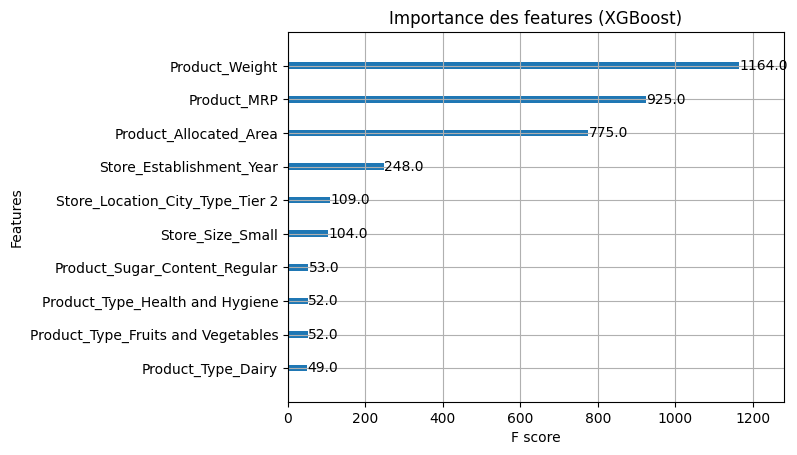

In [42]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# The X_train, X_test, y_train, y_test variables are already available from previous cells,
# so we don't need to redefine them with train_test_split(X, y, ...) again here.
# They still contain the raw categorical columns.

# Access the preprocessor from the previously defined model_pipeline
preprocessor = model_pipeline.named_steps['preprocessor']

# Transform X_train and X_test using the preprocessor
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Initialiser le modèle XGBoost
model_xgb = xgb.XGBRegressor(
    n_estimators=200,       # Nombre d'arbres (boosting rounds)
    learning_rate=0.1,      # Taux d'apprentissage (plus petit = plus précis mais plus lent)
    max_depth=6,            # Profondeur maximale des arbres (évite le surapprentissage)
    subsample=0.8,          # Utilise 80% des données pour chaque arbre (réduit la variance)
    colsample_bytree=0.8,   # Utilise 80% des features pour chaque arbre (réduit la corrélation)
    random_state=42,
    early_stopping_rounds=10,  # Arrête l'entraînement si le score ne s'améliore pas après 10 rounds
    eval_metric='mae'       # Métrique d'évaluation (MAE pour Mean Absolute Error)
)

# Entraînement avec validation croisée
eval_set = [(X_test_processed, y_test)] # Use processed X_test
model_xgb.fit(
    X_train_processed, y_train, # Use processed X_train
    eval_set=eval_set,
    verbose=True  # Affiche la progression
)

# Prédictions
y_pred_xgb = model_xgb.predict(X_test_processed) # Predict on processed X_test

# Évaluation
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"XGBoost - MAE : {mae_xgb:.2f}, R² : {r2_xgb:.2f}")

# Importance des features (pour l'interprétabilité)
# Get feature names after one-hot encoding for plotting
numeric_cols = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year']
categorical_cols = ['Product_Sugar_Content', 'Product_Type', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']

num_feature_names = numeric_cols
cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
all_feature_names = list(num_feature_names) + list(cat_feature_names)

# Assign feature names to the booster model for plotting
model_xgb.get_booster().feature_names = all_feature_names

xgb.plot_importance(model_xgb, max_num_features=10)
plt.title("Importance des features (XGBoost)")
plt.show()

Random Forest - MAE : 114.06, R² : 0.93


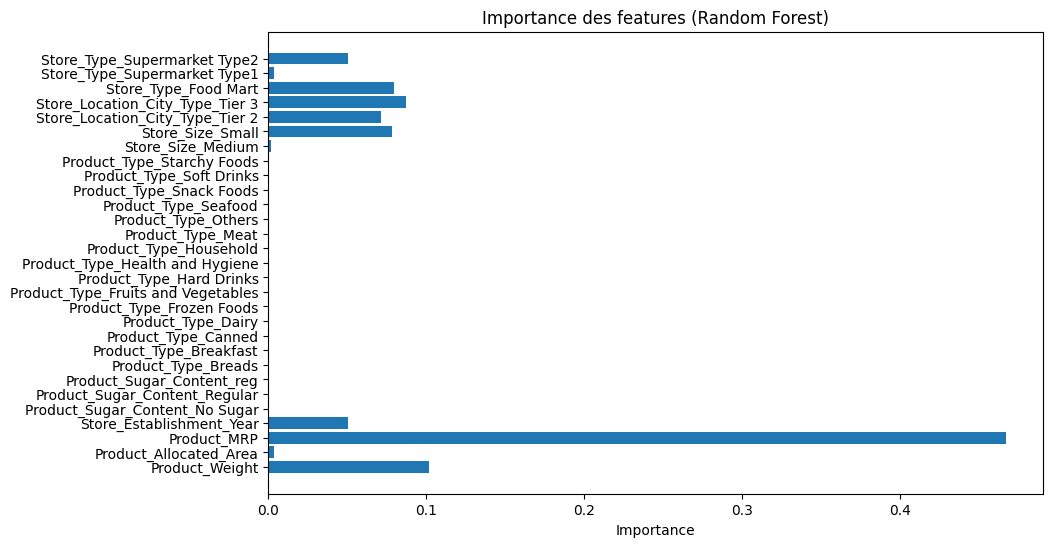

In [44]:
from sklearn.ensemble import RandomForestRegressor

# Initialiser le modèle Random Forest
model_rf = RandomForestRegressor(
    n_estimators=100,       # Nombre d'arbres (plus = meilleur mais plus lent)
    max_depth=10,           # Profondeur maximale des arbres
    min_samples_split=5,    # Nombre minimal d'échantillons pour spliter un nœud
    min_samples_leaf=2,     # Nombre minimal d'échantillons dans une feuille
    random_state=42,
    n_jobs=-1              # Utilise tous les cœurs du CPU
)

# Entraînement avec les données prétraitées
model_rf.fit(X_train_processed, y_train)

# Prédictions sur les données prétraitées
y_pred_rf = model_rf.predict(X_test_processed)

# Évaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest - MAE : {mae_rf:.2f}, R² : {r2_rf:.2f}")

# Importance des features
importances = model_rf.feature_importances_
# Utiliser les noms de fonctionnalités générés après le prétraitement
# Ensure all_feature_names is defined (it should be from cSLBTai4QeNA cell)
if 'all_feature_names' not in globals():
    numeric_cols = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year']
    categorical_cols = ['Product_Sugar_Content', 'Product_Type', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']
    preprocessor = model_pipeline.named_steps['preprocessor']
    num_feature_names = numeric_cols
    cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
    all_feature_names = list(num_feature_names) + list(cat_feature_names)

features = all_feature_names

plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.title("Importance des features (Random Forest)")
plt.xlabel("Importance")
plt.show()

In [48]:
import warnings
warnings.filterwarnings("ignore")

# Gradient Boosting (scikit-learn)
from sklearn.ensemble import GradientBoostingRegressor
model_gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=6)
model_gb.fit(X_train_processed, y_train)

# Prédictions pour Gradient Boosting
y_pred_gb = model_gb.predict(X_test_processed)

# AdaBoost (scikit-learn)
from sklearn.ensemble import AdaBoostRegressor
model_ada = AdaBoostRegressor(n_estimators=100, learning_rate=0.1)
model_ada.fit(X_train_processed, y_train)

# Prédictions pour AdaBoost
y_pred_ada = model_ada.predict(X_test_processed)


In [ ]:
# Évaluation du modèle Gradient Boosting
df_perf_gb = model_performance_regression(model_gb, X_test_processed, y_test)
print("Performance du Gradient Boosting Regressor:")
display(df_perf_gb)

# Évaluation du modèle AdaBoost
df_perf_ada = model_performance_regression(model_ada, X_test_processed, y_test)
print("\nPerformance de l'AdaBoost Regressor:")
display(df_perf_ada)


# **Model Performance Improvement - Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10]
}

search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    params,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42
)
# Correction: Utiliser les données prétraitées X_train_processed
search.fit(X_train_processed, y_train)
print("Meilleurs paramètres :", search.best_params_)


# **Model Performance Comparison, Final Model Selection, and Serialization**

# **Deployment - Backend**

## Flask Web Framework


## Dependencies File

## Dockerfile

## Setting up a Hugging Face Docker Space for the Backend

## Uploading Files to Hugging Face Space (Docker Space)

# **Deployment - Frontend**

## Points to note before executing the below cells
- Create a Streamlit space on Hugging Face by following the instructions provided on the content page titled **`Creating Spaces and Adding Secrets in Hugging Face`** from Week 1

## Streamlit for Interactive UI

## Dependencies File

## DockerFile

In [31]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

Writing frontend_files/Dockerfile


FileNotFoundError: [Errno 2] No such file or directory: 'frontend_files/Dockerfile'

## Uploading Files to Hugging Face Space (Streamlit Space)

# **Actionable Insights and Business Recommendations**

-

-